# False positive rate of recombinant detection vs k

Synthetic single-breakpoint Alpha x Delta recombinants, spliced from real UK
sequences collected on 2021-05-16, matched against the raw inference ARG for
2021-05-15 with `sc2ts run-hmm`. Real sequences held out of the parent pool act
as non-recombinant controls, so a control matched to more than one parent is a
false positive.

See `simulations/synthetic_recombinants/` for the workflow. This reads the
pilot run: 50 recombinants and 50 controls at each of k = 3, 4, 5.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

In [2]:
df = pd.read_csv(
    Path("../simulations/synthetic_recombinants/pilot") / "results.csv"
)
# Only recombinants have these, so they arrive as object with blanks.
for column in ["lineages_correct", "breakpoint_correct"]:
    df[column] = df[column].astype("boolean")
# How many sites separate the parents on the sparser side of the true
# breakpoint. A recombinant with none here cannot be detected for any k.
df["min_informative"] = np.minimum(
    df.num_informative_left, df.num_informative_right
)
recombinants = df[df.type == "recombinant"]
controls = df[df.type == "control"]
k_values = sorted(df.k.unique())
len(df), k_values

(300, [np.int64(3), np.int64(4), np.int64(5)])

In [3]:
# k is ordered, so it gets one hue stepped light to dark rather than three
# unrelated colours.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
recombinant_color = "#2a78d6"
control_color = "#eb6834"
grid_kwargs = dict(color="0.9", linewidth=0.6)

## Summary

`fp_upper_95` is the one-sided 95% Clopper-Pearson upper bound on the false
positive rate, which is what 0 out of 50 controls actually buys us.

In [4]:
rows = []
for k in k_values:
    rec = recombinants[recombinants.k == k]
    ctl = controls[controls.k == k]
    detected = rec[rec.detected]
    n_fp = int(ctl.detected.sum())
    rows.append(
        {
            "k": k,
            "n_controls": len(ctl),
            "false_positives": n_fp,
            "fp_rate": n_fp / len(ctl),
            "fp_upper_95": scipy.stats.beta.ppf(
                0.95, n_fp + 1, len(ctl) - n_fp
            ),
            "n_recombinants": len(rec),
            "detection_rate": rec.detected.mean(),
            "lineages_correct": detected.lineages_correct.mean(),
            "breakpoint_correct": detected.breakpoint_correct.mean(),
            "median_bp_error": detected.breakpoint_error.median(),
            "median_cost": rec.hmm_cost.median(),
            "frac_cost_above_7": (rec.hmm_cost > 7).mean(),
        }
    )
summary = pd.DataFrame(rows).set_index("k")
summary.round(3)

,n_controls,false_positives,fp_rate,fp_upper_95,n_recombinants,detection_rate,lineages_correct,breakpoint_correct,median_bp_error,median_cost,frac_cost_above_7
k,,,,,,,,,,,
3,50,0,0.0,0.058,50,0.90,0.933,0.844,715.0,3.0,0.02
4,50,0,0.0,0.058,50,0.86,0.930,0.860,669.0,4.0,0.02
5,50,0,0.0,0.058,50,0.82,0.976,0.878,647.0,5.0,0.02


## Why recombinants are missed

Detection needs the sparser side of the breakpoint to carry more mismatches
than the recombination penalty k, otherwise a single-parent match plus a few
mutations is the cheaper explanation. Every miss in this run sits in the
left-hand bins.

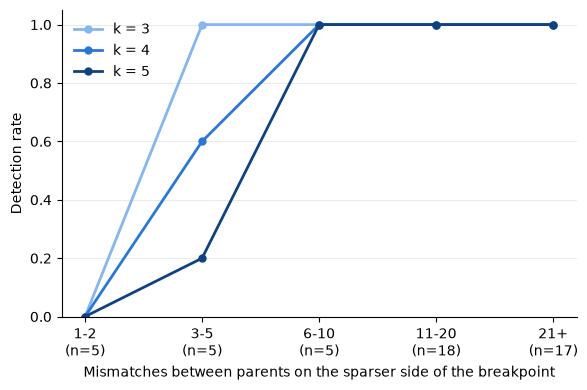

In [5]:
bins = [0, 2, 5, 10, 20, np.inf]
labels = ["1-2", "3-5", "6-10", "11-20", "21+"]

fig, ax = plt.subplots(figsize=(6, 4))
for k in k_values:
    rec = recombinants[recombinants.k == k].copy()
    rec["bin"] = pd.cut(rec.min_informative, bins=bins, labels=labels)
    rate = rec.groupby("bin", observed=False).detected.mean()
    ax.plot(
        range(len(labels)),
        rate.values,
        marker="o",
        markersize=5,
        linewidth=2,
        color=k_colors[k],
        label=f"k = {k}",
    )

counts = (
    pd.cut(
        recombinants[recombinants.k == k_values[0]].min_informative,
        bins=bins,
        labels=labels,
    )
    .value_counts()
    .reindex(labels)
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f"{label}\n(n={n})" for label, n in counts.items()])
ax.set_xlabel("Mismatches between parents on the sparser side of the breakpoint")
ax.set_ylabel("Detection rate")
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, **grid_kwargs)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## HMM cost

A single-parent match pays no recombination penalty, so control costs are
identical across k. Recombinant cost sits at k plus any extra mutations, which
pushes some genuine recombinants past the `hmm_cost_threshold = 7` used in the
real inference, independently of whether the HMM found the recombination.

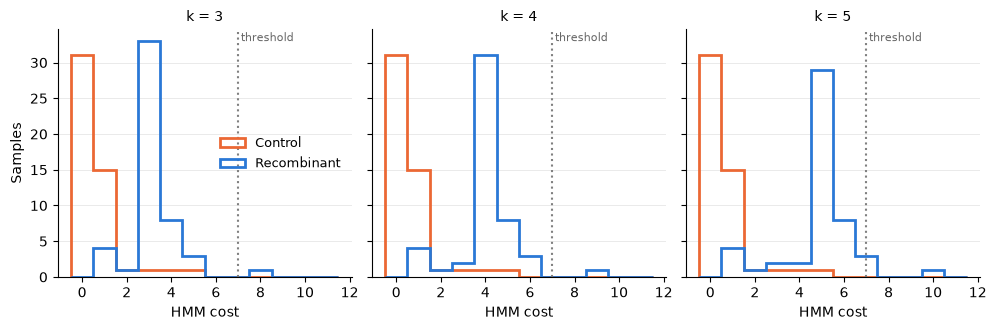

In [6]:
fig, axes = plt.subplots(1, len(k_values), figsize=(10, 3.4), sharey=True)
edges = np.arange(-0.5, 12)
for ax, k in zip(axes, k_values):
    for data, color, label in [
        (controls[controls.k == k].hmm_cost, control_color, "Control"),
        (
            recombinants[recombinants.k == k].hmm_cost,
            recombinant_color,
            "Recombinant",
        ),
    ]:
        ax.hist(
            data,
            bins=edges,
            histtype="step",
            linewidth=2,
            color=color,
            label=label,
        )
    ax.axvline(7, color="0.5", linestyle=":", linewidth=1.5)
    ax.annotate(
        "threshold",
        xy=(7, ax.get_ylim()[1]),
        xytext=(2, -2),
        textcoords="offset points",
        va="top",
        fontsize=8,
        color="0.4",
    )
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xlabel("HMM cost")
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("Samples")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()

## Breakpoint accuracy

For detected recombinants, how far the inferred switch sits from the true
breakpoint. The floor is set by the spacing of the sites that distinguish the
parents, which is of order several hundred bases given that Alpha and Delta
differ at roughly 60 sites across the genome.

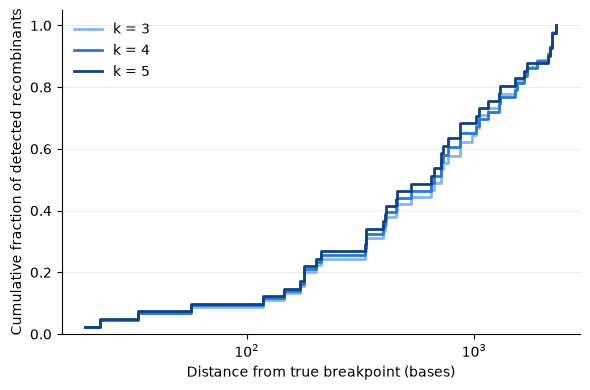

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for k in k_values:
    detected = recombinants[(recombinants.k == k) & recombinants.detected]
    error = np.sort(detected.breakpoint_error.values)
    ax.step(
        error,
        np.arange(1, len(error) + 1) / len(error),
        where="post",
        linewidth=2,
        color=k_colors[k],
        label=f"k = {k}",
    )
ax.set_xscale("symlog", linthresh=100)
ax.set_xlabel("Distance from true breakpoint (bases)")
ax.set_ylabel("Cumulative fraction of detected recombinants")
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, **grid_kwargs)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## Caveats

- The false positive rate rests on 50 controls, so 0 observed only bounds it
  below about 6%. The full run uses all 338 controls, which would tighten the
  bound to about 1%.
- `breakpoint_correct` is judged against the informative sites of the *true*
  parents, but the HMM matches nodes in the ARG that are relatives of those
  parents rather than the parents themselves, so it is a strict criterion.
  `breakpoint_error` is the more robust measure.
- Breakpoints are drawn uniformly over the genome and kept even when they leave
  the parents indistinguishable on one side, so the unconditional detection
  rate understates performance on recombinants that carry real signal.